# Exploración del ambiente

Este notebook sirve para familiarizarse con el ambiente antes de entrenar. Cargamos el entorno, verificamos el espacio de acciones, la codificación del estado y ejecutamos algunos pasos manuales para confirmar que las recompensas por subtarea (recoger llave, mover bola, abrir puerta) se disparan correctamente.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

from src.minigrid.env import DoorKeyEnv, ACTIONS

env = DoorKeyEnv(seed=0)
state, info = env.reset()
print('Estado inicial:', state)
print('Acciones disponibles:', ACTIONS)
print('Número de acciones:', env.n_actions)

C:\Users\LaraJ\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Estado inicial: ((np.int64(3), np.int64(3)), 3, 'none', False, False, False, False, False)
Acciones disponibles: {0: 'left', 1: 'right', 2: 'forward', 3: 'pickup', 4: 'drop', 5: 'toggle'}
Número de acciones: 6


## Visualización

MiniGrid devuelve frames como arreglos RGB. Usamos matplotlib para inspeccionar la grilla y validar la posición inicial del agente, la llave, la bola y la puerta.

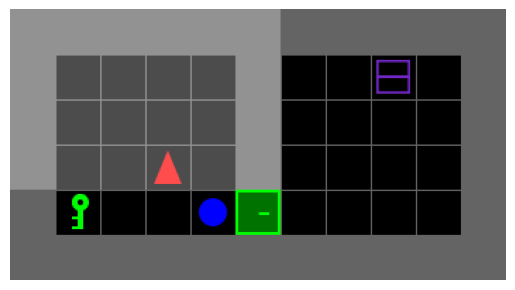

In [2]:
import matplotlib.pyplot as plt

frame = env.render()
plt.imshow(frame)
plt.axis('off')
plt.show()

## Ejecución manual de acciones

Probamos una secuencia corta para validar la codificación del estado y el shaping de recompensa.

In [3]:
for a in [2, 2, 1, 2, 3]:
    s, r, terminated, truncated, _ = env.step(a)
    print(f'acción={ACTIONS[a]:<8} estado={s} recompensa={r:+.3f} done={terminated or truncated}')
    if terminated or truncated:
        break

acción=forward  estado=((np.int64(3), np.int64(2)), 3, 'none', False, False, False, False, False) recompensa=-0.001 done=False
acción=forward  estado=((np.int64(3), np.int64(1)), 3, 'none', False, False, False, False, False) recompensa=-0.001 done=False
acción=right    estado=((np.int64(3), np.int64(1)), 0, 'none', False, False, False, False, False) recompensa=-0.001 done=False
acción=forward  estado=((np.int64(4), np.int64(1)), 0, 'none', False, False, False, False, False) recompensa=-0.001 done=False
acción=pickup   estado=((np.int64(4), np.int64(1)), 0, 'none', False, False, False, False, False) recompensa=-0.001 done=False
